In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm.notebook import tqdm
import random
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

cuda


In [2]:
from google.colab import files #
file_uploaded=files.upload()

Saving apple.zip to apple.zip


In [ ]:
!unzip apple.zip

In [4]:
blotch_directory = 'blotch/'
normal_directory = 'normal/'
rot_directory = 'rot/'
scab_directory = 'scab/'


blotch_images_filepaths = sorted([os.path.join(blotch_directory, f) for f in os.listdir(blotch_directory)])
normal_images_filepaths = sorted([os.path.join(normal_directory, f) for f in os.listdir(normal_directory)])
rot_images_filepaths = sorted([os.path.join(rot_directory, f) for f in os.listdir(rot_directory)])
scab_images_filepaths = sorted([os.path.join(scab_directory, f) for f in os.listdir(scab_directory)])
images_filepaths = [*blotch_images_filepaths, *normal_images_filepaths, *rot_images_filepaths, *scab_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

In [ ]:
blotch_directory = 'test/blotch/'
normal_directory = 'test/normal/'
rot_directory = 'test/rot/'
scab_directory = 'test/scab/'


blotch_images_filepaths = sorted([os.path.join(blotch_directory, f) for f in os.listdir(blotch_directory)])
normal_images_filepaths = sorted([os.path.join(normal_directory, f) for f in os.listdir(normal_directory)])
rot_images_filepaths = sorted([os.path.join(rot_directory, f) for f in os.listdir(rot_directory)])
scab_images_filepaths = sorted([os.path.join(scab_directory, f) for f in os.listdir(scab_directory)])
images_filepaths = [*blotch_images_filepaths, *normal_images_filepaths, *rot_images_filepaths, *scab_images_filepaths]
test_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

In [6]:
print(len(correct_images_filepaths))

320


In [7]:
from numpy.lib import test
random.seed(1)
random.shuffle(correct_images_filepaths)

train_images_filepaths = correct_images_filepaths[:290]
val_images_filepaths = correct_images_filepaths[290:]
test_images_filepaths = correct_images_filepaths[-10:]
print('train:', len(train_images_filepaths))
print('val:', len(val_images_filepaths))
print('test:', len(test_images_filepaths))

print(train_images_filepaths)

train: 290
val: 30
test: 10
['rot/rot.43.jpg', 'rot/rot.55.jpg', 'rot/rot.68.jpg', 'rot/rot.75.jpg', 'rot/rot.41.jpg', 'rot/rot.30.jpg', 'blotch/blotch.72.jpg', 'rot/rot.62.jpg', 'rot/rot.79.jpg', 'blotch/blotch.36.jpg', 'normal/normal.23.jpg', 'blotch/blotch.42.jpg', 'rot/rot.47.jpg', 'scab/scab.39.jpg', 'normal/normal.8.jpg', 'rot/rot.36.jpg', 'normal/normal.30.jpg', 'scab/scab.31.jpg', 'scab/scab.2.jpg', 'rot/rot.9.jpg', 'normal/normal.26.jpg', 'normal/normal.1.jpg', 'blotch/blotch.26.jpg', 'blotch/blotch.53.jpg', 'rot/rot.20.jpg', 'rot/rot.76.jpg', 'rot/rot.74.jpg', 'scab/scab.65.jpg', 'scab/scab.66.jpg', 'normal/normal.34.jpg', 'normal/normal.37.jpg', 'normal/normal.50.jpg', 'normal/normal.62.jpg', 'scab/scab.61.jpg', 'scab/scab.38.jpg', 'blotch/blotch.6.jpg', 'blotch/blotch.4.jpg', 'scab/scab.21.jpg', 'blotch/blotch.40.jpg', 'rot/rot.65.jpg', 'blotch/blotch.65.jpg', 'rot/rot.24.jpg', 'scab/scab.6.jpg', 'blotch/blotch.78.jpg', 'normal/normal.28.jpg', 'rot/rot.14.jpg', 'blotch/blot

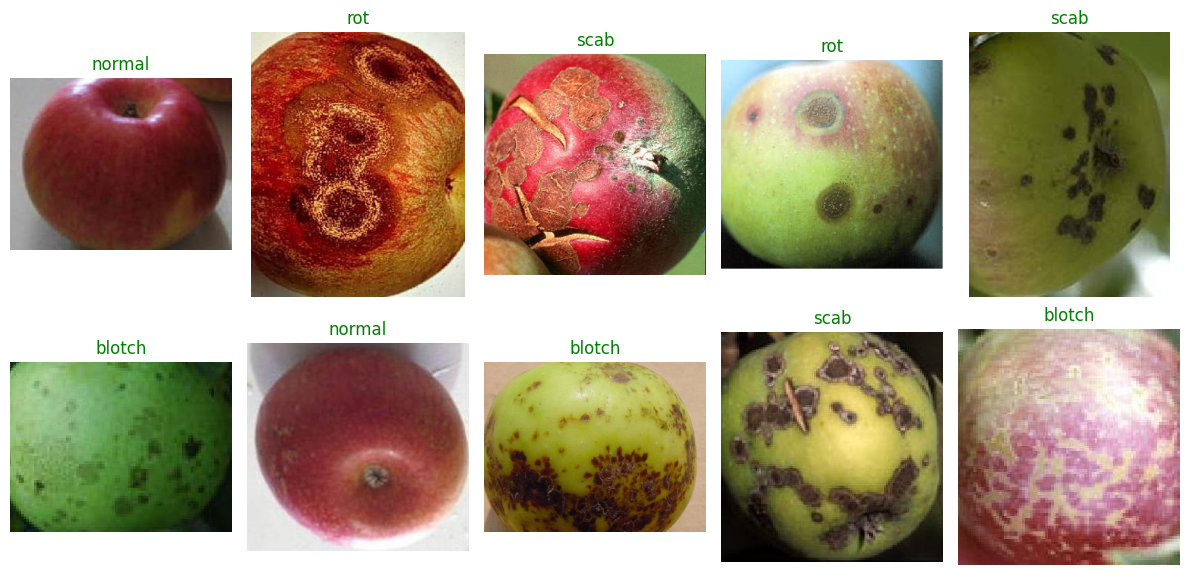

In [8]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
        predicted_label = predicted_labels[i] if predicted_labels else true_label
        color = "green" if true_label == predicted_label else "red"
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(predicted_label, color=color)
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
display_image_grid(test_images_filepaths)

In [9]:
class AppleDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list
        self.transform = transform
        self.phase = phase

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0] # for example, bloth.75.jpg -> blotch
        if label == 'blotch':
            label = 0
        elif label == 'normal':
            label = 1
        if label == 'rot':
            label = 2
        elif label == 'scab':
            label = 3
        return img_transformed, label

In [10]:
size = 256
mean = (0.485, 0.456, 0.406) # RGB
std = (0.229, 0.224, 0.225) #RGB
batch_size = 32
train_dataset = AppleDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
test_dataset = AppleDataset(test_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print('image size:', train_dataset.__getitem__(index)[0].size())
print('image label:', train_dataset.__getitem__(index)[1])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

image size: torch.Size([3, 256, 256])
image label: 2
torch.Size([32, 3, 256, 256])
tensor([3, 1, 1, 1, 0, 3, 0, 0, 1, 0, 3, 0, 3, 2, 1, 2, 3, 0, 3, 2, 0, 1, 3, 0,
        2, 3, 0, 3, 2, 2, 0, 0])


In [11]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU() # activation
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        self.cnn3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=1)
        self.relu3 = nn.ReLU() # activation
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(64*29*29, 1024)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(1024, 512)
        self.relu5 = nn.ReLU()
        self.fc3 = nn.Linear(512, 4)

        self.output = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.cnn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        out = self.fc3(out)
        out = self.output(out)
        return out

In [12]:
model = LeNet().to(device)
print(model)
from torchsummary import summary
summary(model, input_size=(3, 256, 256))

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=53824, out_features=1024, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (relu5): ReLU()
  (fc3): Linear(in_features=512, out_features=4, bias=True)
  (output): Softmax(dim=1)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 252, 252]           1,216
              ReLU-2         [-

In [13]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
#optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()
model = model.to(device)
criterion = criterion.to(device)
import time

def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))
    return model

In [14]:
num_epoch = 50
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/50
--------------------


  0%|          | 0/10 [00:00<?, ?it/s]

train Loss: 1.3864 Acc: 0.2483


  0%|          | 0/1 [00:00<?, ?it/s]

val Loss: 1.3859 Acc: 0.4000
Epoch 2/50
--------------------


...

val Loss: 1.2081 Acc: 0.4000
Epoch 50/50
--------------------


  0%|          | 0/10 [00:00<?, ?it/s]

train Loss: 1.1167 Acc: 0.6276


  0%|          | 0/1 [00:00<?, ?it/s]

val Loss: 1.2371 Acc: 0.5000
Training complete in 1m 13s
Best val Acc: 0.600000


In [ ]:
import pandas as pd

corrects = 0
_id=0

with torch.no_grad():
    for test_path in tqdm(test_images_filepaths):
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        if test_path.split('/')[-1].split('.')[0] == 'blotch':
            label = 0
        elif test_path.split('/')[-1].split('.')[0] == 'normal':
            label = 1
        elif test_path.split('/')[-1].split('.')[0] == 'rot':
            label = 2
        else:
            label = 3
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        corrects += torch.sum(preds == label)

acc = (corrects / len(test_images_filepaths)).cpu().numpy()
print('Test Acc: {:4f}'.format(acc ))


  0%|          | 0/20 [00:00<?, ?it/s]

Test Acc: 0.600000
